In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


sdi2100098 : Πάντιος Ματιάτος

sdi2100070 : Ιωάννης Κούβελας

In [2]:
import pandas as pd
import traceback
import numpy as np
import os

def solve(folder_path_ : dict , csv_files : list,col : list ) -> None :
  # Create a list to hold the dataframes
  df_list_19 = []
  df_list_23 = []
  for index,csv_list in enumerate(csv_files):
      for csv in csv_list :
        #choose the right folder path
          if index == 0 :
              folder_path = folder_path_.get('folder_path_2019_april')
          elif index == 1 :
              folder_path = folder_path_.get('folder_path_2019_march')
          elif index == 2 :
              folder_path = folder_path_.get('folder_path_2019_febrouary')
          elif index == 3 :
              folder_path = folder_path_.get('folder_path_2023_june')
          elif index == 4 :
              folder_path = folder_path_.get('folder_path_2023_march')
          else :
              folder_path = folder_path_.get('folder_path_2023_september')

          file_path = os.path.join(folder_path, csv)
          try:
              # Try reading the file using default UTF-8 encoding
              df = pd.read_csv(file_path, usecols=lambda x: x in col ,keep_default_na=False,on_bad_lines='error', index_col=False, dtype='unicode').sample(n=6000)
              df = df.replace(r'^\s*$', 'N/A', regex=True)
              #clear extreme values
              for column in col :
                if column in ['bedrooms','beds', 'review_scores_rating','bathrooms'] :
                  df[column] = df[column].astype(str).str.split('.').str[0]
                #convert price column to float
                if column == 'price' :
                  df[column] = df[column].replace('\$|,', '', regex=True)
                  df[column] = pd.to_numeric(df[column])
                #replace greek characters with N/A (to drop it later)
                if column == 'neighbourhood_cleansed' :
                  df = df.replace(r'\n','N/A', regex=True)
                  df[column].replace('.*N/A.*', 'N/A', regex=True, inplace=True)
              #drop the rows and columns that have N/A cells(empty cells)
              df = df.replace('N/A', pd.NA).dropna(axis = 1 , how = 'all')
              df = df.replace('N/A', pd.NA).dropna()
              if index >=0 and index <=2 :
                  df_list_19.append(df)
              else :
                  df_list_23.append(df)
          except UnicodeDecodeError:
              try:
                  # If UTF-8 fails, try reading the file using UTF-16 encoding with tab separator
                  df = pd.read_csv(file_path, usecols=lambda x: x in col , keep_default_na=False, sep='\t',encoding='utf-16', on_bad_lines='error', index_col=False, dtype='unicode').sample(n=6000)
                  df = df.replace(r'^\s*$', 'N/A', regex=True)
                  #clear extreme values
                  for column in col :
                    if column in ['bedrooms','beds', 'review_scores_rating','bathrooms'] :
                      df[column] = df[column].astype(str).str.split('.').str[0]
                    #convert price column to float
                    if column == 'price' :
                      df[column] = df[column].replace('\$|,', '', regex=True)
                      df[column] = pd.to_numeric(df[column])
                    #replace greek characters with N/A (to drop it later)
                    if column == 'neighbourhood_cleansed' :
                      df = df.replace(r'\n','N/A', regex=True)
                      df[column].replace('.*N/A.*', 'N/A', regex=True, inplace=True)
                  #drop the rows and columns that have N/A cells(empty cells)
                  df = df.replace('N/A', pd.NA).dropna(axis = 1 , how = 'all')
                  df = df.replace('N/A', pd.NA).dropna()
                  if index >=0 and index <=2 :
                      df_list_19.append(df)
                  else :
                      df_list_23.append(df)
              except Exception as e:
                  print(f"Could not read file {csv} for folder : {folder_path} because of error: {e} and column : {df.columns}")
          except Exception as e:
              print(f"Could not read file {csv} for folder : {folder_path} because of error: {e} and column : {df.columns}")

  # Concatenate all data into one DataFrame
  big_df_19 = pd.concat(df_list_19, ignore_index=True)
  big_df_23 = pd.concat(df_list_23, ignore_index=True)

  # Save the final result to a new CSV file
  big_df_19.to_csv(os.path.join(folder_path_.get('destination_path_19'), 'train_2019.csv'), index=False)
  big_df_23.to_csv(os.path.join(folder_path_.get('destination_path_23'), 'train_2023.csv'), index=False)

def main () :

    # replace with your folder's path
    folder_path = {
        'folder_path_2019_april' : '/content/drive/MyDrive/2019/april',
        'folder_path_2019_march' : '/content/drive/MyDrive/2019/march',
        'folder_path_2019_febrouary' : '/content/drive/MyDrive/2019/febrouary',
        'folder_path_2023_june' : '/content/drive/MyDrive/2023/june',
        'folder_path_2023_march' : '/content/drive/MyDrive/2023/march',
        'folder_path_2023_september' : '/content/drive/MyDrive/2023/september',
        'destination_path_19' : '/content/drive/MyDrive/2019',
        'destination_path_23' : '/content/drive/MyDrive/2023',
    }

    col = ['id','zipcode','transit','bedrooms','beds','review_scores_rating','number_of_reviews','neighbourhood_cleansed','name','latitude','longitude','last_review','instant_bookable','host_since','host_response_rate','host_identity_verified','host_has_profile_pic','first_review','description','city','cancellation_policy','bed_type','bathrooms','accommodates','amenities','room_type','property_type','price','availability_365','minimum_nights','host_id']
    all_files = {
      "all_files_19_ap" : os.listdir(folder_path.get("folder_path_2019_april")),
      "all_files_19_m" : os.listdir(folder_path.get("folder_path_2019_march")),
      "all_files_19_f" : os.listdir(folder_path.get("folder_path_2019_febrouary")),
      "all_files_23_june" : os.listdir(folder_path.get("folder_path_2023_june")),
      "all_files_23_m" : os.listdir(folder_path.get("folder_path_2023_march")),
      "all_files_23_sept" : os.listdir(folder_path.get("folder_path_2023_september")),
    }

    # Filter out non-CSV files
    csv_files_19_ap = [f for f in all_files.get("all_files_19_ap") if f.endswith('listings.csv')]
    csv_files_19_m = [f for f in all_files.get("all_files_19_m") if f.endswith('listings.csv')]
    csv_files_19_f = [f for f in all_files.get("all_files_19_f") if f.endswith('listings.csv')]
    csv_files_23_june = [f for f in all_files.get("all_files_23_june") if f.endswith('listings.csv')]
    csv_files_23_m = [f for f in all_files.get("all_files_23_m") if f.endswith('listings.csv')]
    csv_files_23_sept = [f for f in all_files.get("all_files_23_sept") if f.endswith('listings.csv')]
    csv_files = [csv_files_19_ap,csv_files_19_m,csv_files_19_f,csv_files_23_june,csv_files_23_m,csv_files_23_sept]
    #call solve function to clear the csv files accordingly and then merge them also!
    solve(folder_path,csv_files,col)


if __name__ == '__main__':
    main()

-----Now printing for 2019-----


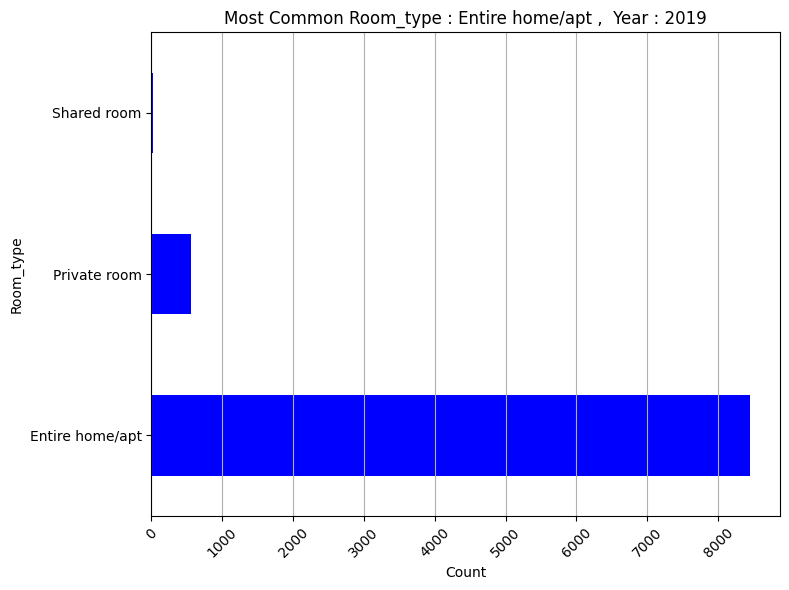

-----Now printing for 2023------


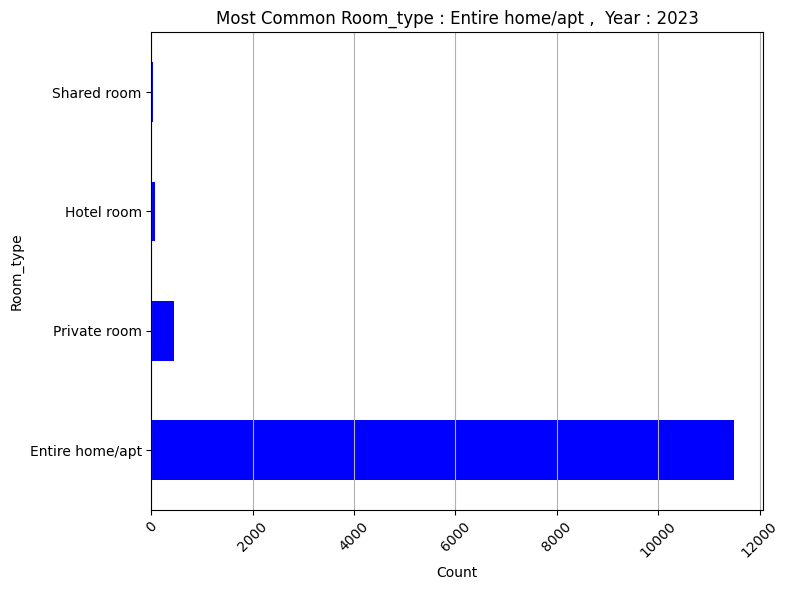

In [ ]:
#Question 1.1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_find_element(csv_file, column_name):
  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(csv_file)

  # Get the most common element in the specified column
  most_common = df[column_name].mode()[0]

  # Count occurrences of each element in the column
  counts = df[column_name].value_counts()

  # Plot the counts
  plt.figure(figsize=(8, 6))
  counts.plot(kind='barh', color='blue')
  plt.title(f'Most Common {column_name.capitalize()} : {most_common} ,  Year : {csv_file[23 : 27]}')
  plt.xlabel('Count')
  plt.ylabel(column_name.capitalize())
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.grid(axis = 'x')
  if csv_file[23 : 27] == '2019' :
    plt.savefig('question_1_1_2019.png')
  else :
    plt.savefig('question_1_1_2023.png')
  plt.show()


def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  type_ = 'room_type'
  plot_find_element(file_name_19,type_)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  plot_find_element(file_name_23,type_)


if __name__ == '__main__' :
  main()

-----Now printing for 2019-----


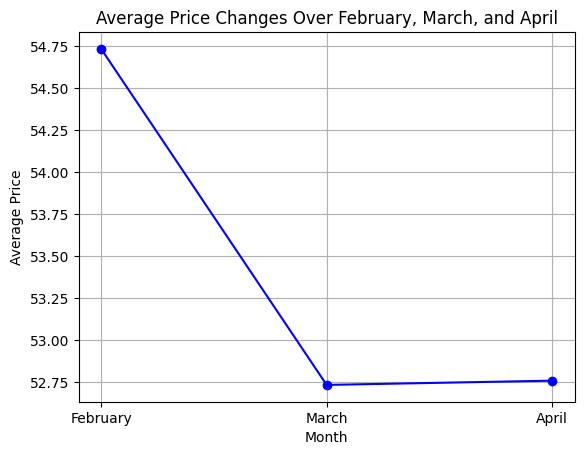

-----Now printing for 2023------


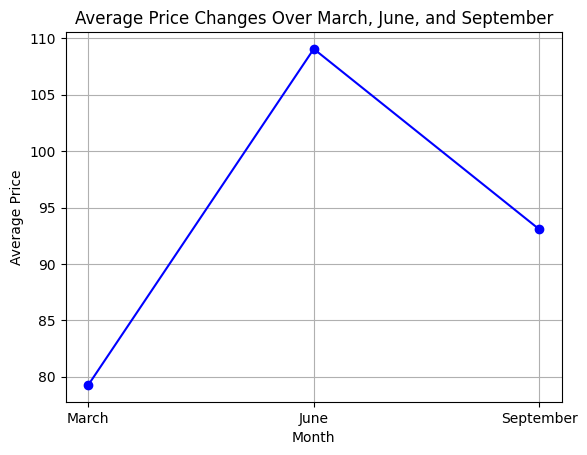

In [ ]:
#Question 1.2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def price_analysis(csv_file) :
  df = pd.read_csv(csv_file)
  # Convert 'last_review' column to datetime
  df['last_review'] = pd.to_datetime(df['last_review'])

  # Extract month from 'last_review'
  df['month'] = df['last_review'].dt.month

  # Filter data for February, March, and April for 2019 and March, June, September for 2023
  if csv_file[23 : 27] == '2019' :
    df_filtered = df[df['month'].isin([2, 3, 4])]
  else :
    df_filtered = df[df['month'].isin([3, 6, 9])]

  # Group by month and calculate mean price for each month
  monthly_prices = df_filtered.groupby('month')['price'].mean()

  # Plotting
  plt.plot(monthly_prices.index, monthly_prices.values, marker='o', linestyle='-',color = 'blue')
  if csv_file[23 : 27] == '2019' :
    plt.title('Average Price Changes Over February, March, and April')
    plt.xticks([2, 3, 4], ['February', 'March', 'April'])
  else :
    plt.title('Average Price Changes Over March, June, and September')
    plt.xticks([3, 6, 9], ['March', 'June', 'September'])
  plt.xlabel('Month')
  plt.ylabel('Average Price')
  plt.grid(True)
  if csv_file[23 : 27] == '2019' :
    plt.savefig('question_1_2_2019.png')
  else :
    plt.savefig('question_1_2_2023.png')
  plt.show()


def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  price_analysis(file_name_19)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  price_analysis(file_name_23)


if __name__ == '__main__' :
  main()

-----Now printing for 2019-----


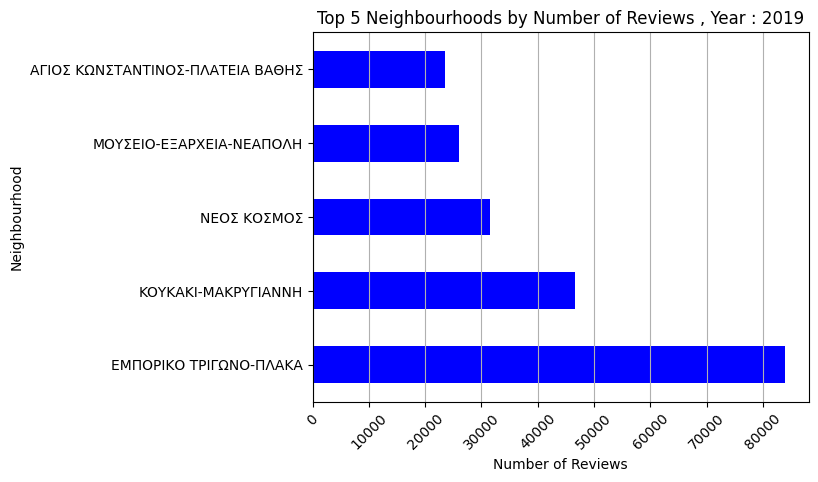

-----Now printing for 2023------


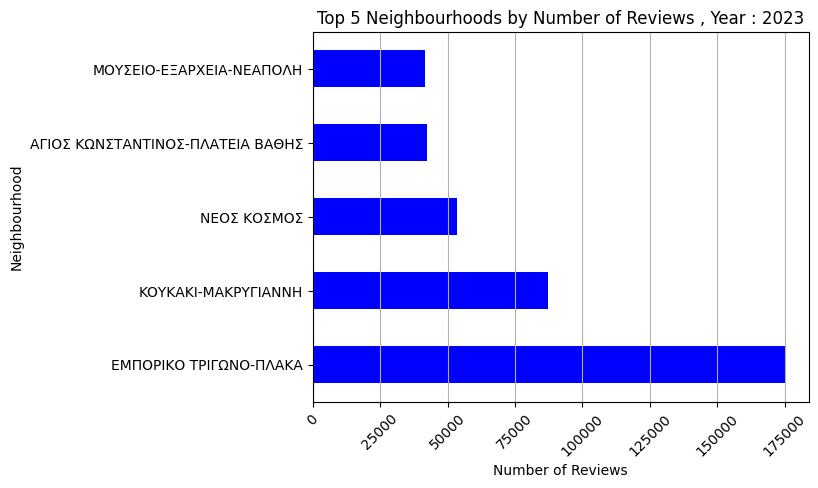

In [ ]:
#Question 1.3
import pandas as pd
import matplotlib.pyplot as plt

def find_neighbourhoods(csv_file) :

  # Load the CSV file
  df = pd.read_csv(csv_file)

  # Group by neighbourhood and sum number_of_reviews
  group_neigh_reviews = df.groupby('neighbourhood_cleansed')['number_of_reviews'].sum()

  # Sort the neighbourhoods by number of reviews
  top_5_neighbourhoods = group_neigh_reviews.sort_values(ascending=False).head(5)

  # Plotting
  top_5_neighbourhoods.plot(kind='barh', color='blue')
  plt.title(f'Top 5 Neighbourhoods by Number of Reviews , Year : {csv_file[23 : 27]}')
  plt.xlabel('Number of Reviews')
  plt.ylabel('Neighbourhood')
  plt.xticks(rotation=45)
  plt.grid(axis='x')
  if csv_file[23 : 27] == '2019' :
    plt.savefig('question_1_3_2019.png')
  else :
    plt.savefig('question_1_3_2023.png')
  plt.show()


def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  find_neighbourhoods(file_name_19)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  find_neighbourhoods(file_name_23)


if __name__ == '__main__' :
  main()

-----Now printing for 2019-----


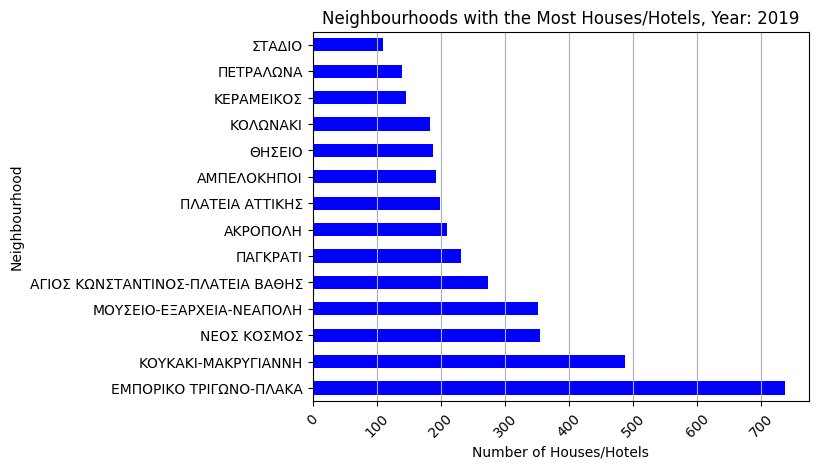

-----Now printing for 2023------


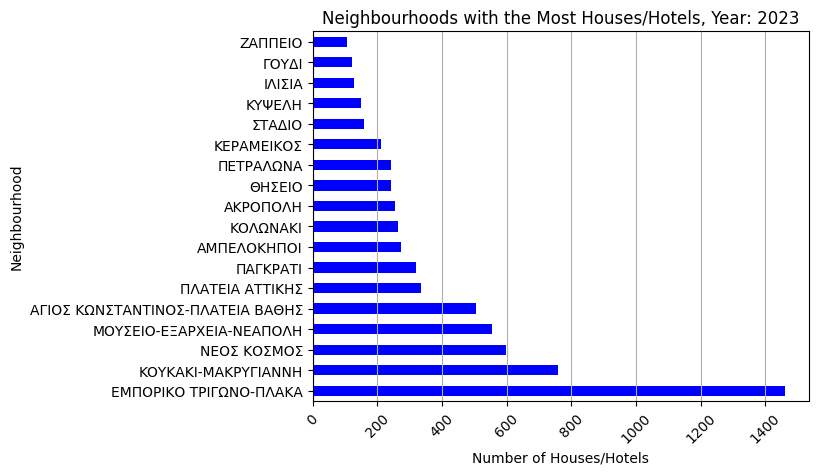

In [ ]:
#Question 1.4
import pandas as pd
import matplotlib.pyplot as plt

def find_right_neighbourhoods(csv_list, min_count=100):
  # Load the CSV file
  df = pd.read_csv(csv_list)

  # Group by neighbourhood and count unique IDs
  group_neighbourhood_id = df.groupby('neighbourhood_cleansed')['id'].nunique()

  # Filter out neighborhoods with counts below the minimum
  group_neighbourhood_id = group_neighbourhood_id[group_neighbourhood_id >= min_count]

  # Sort the remaining neighborhoods by number of houses/hotels
  sort_neighbourhood = group_neighbourhood_id.sort_values(ascending=False)

  # Plotting
  sort_neighbourhood.plot(kind='barh', color='blue')
  plt.title(f'Neighbourhoods with the Most Houses/Hotels, Year: {csv_list[23:27]}')
  plt.xlabel('Number of Houses/Hotels')
  plt.ylabel('Neighbourhood')
  plt.xticks(rotation=45)
  plt.grid(axis='x')
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_4_2019.png')
  else :
    plt.savefig('question_1_4_2023.png')
  plt.show()


def main():
  # 2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  find_right_neighbourhoods(file_name_19)
  # 2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  find_right_neighbourhoods(file_name_23)

if __name__ == '__main__':
  main()


-----Now printing for 2019-----


<ipython-input-7-2f5001eccb4d>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['entries'] = 365 - df_filtered['availability_365']


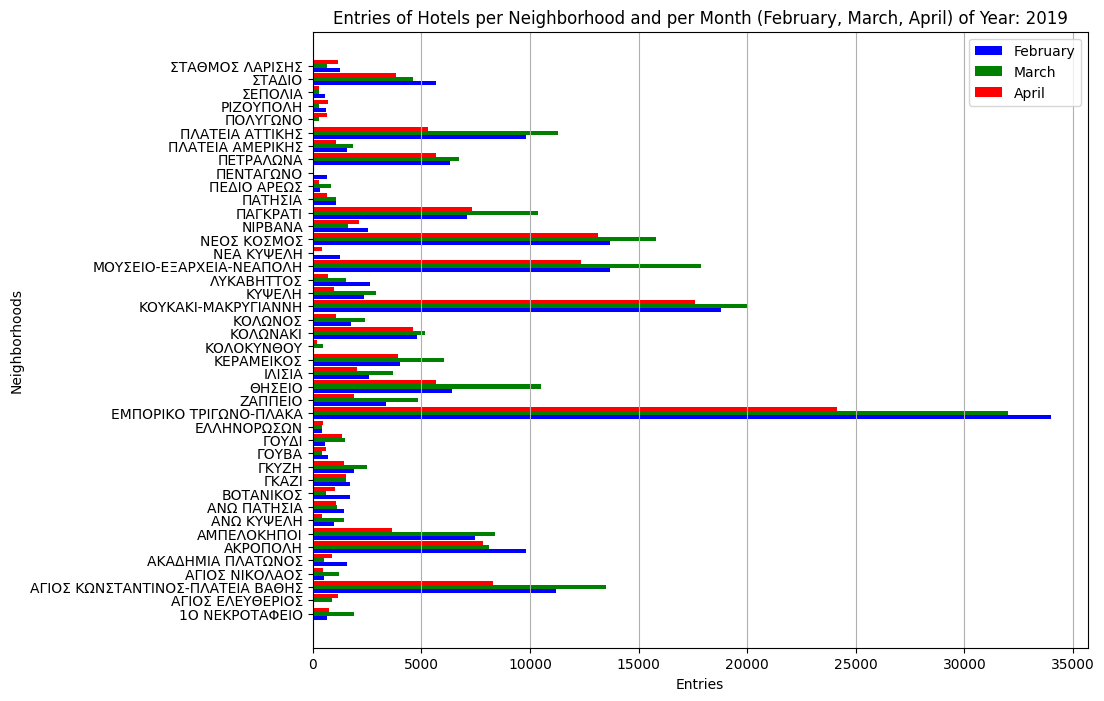

-----Now printing for 2023------


<ipython-input-7-2f5001eccb4d>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['entries'] = 365 - df_filtered['availability_365']


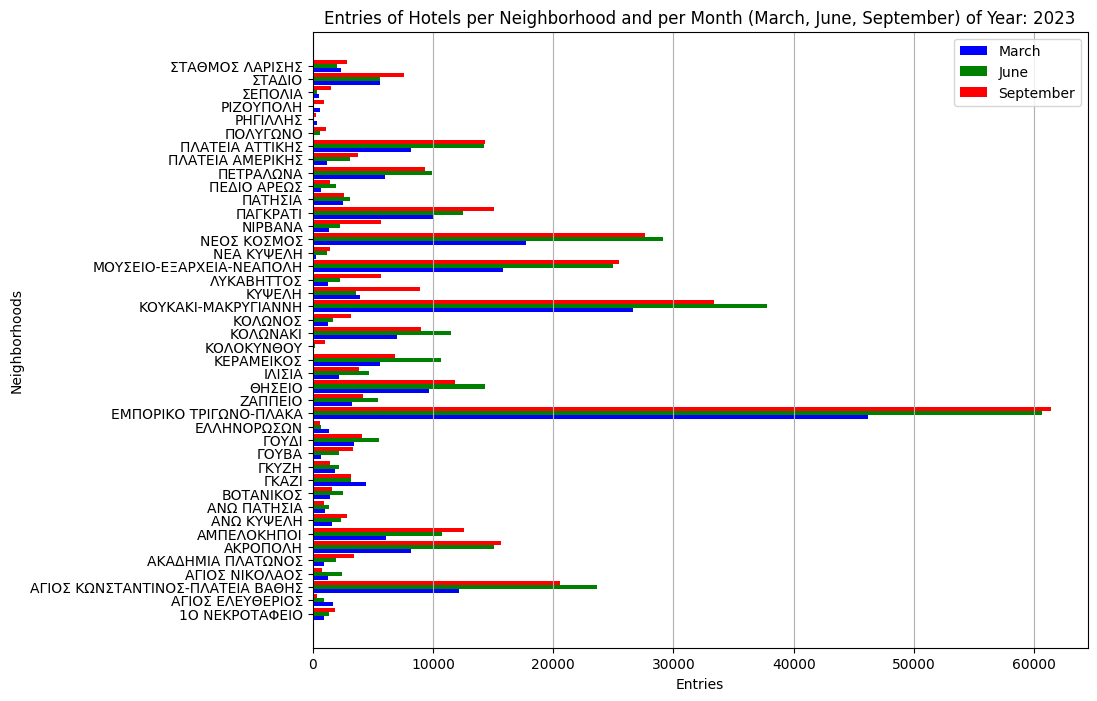

In [ ]:
#Question 1.5
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def entries(csv_list,min_count = 500):
  # Read the CSV file into a DataFrame
  df = pd.read_csv(csv_list)

  if csv_list[23:27] == '2019':
      name_ = '(February, March, April)'
  else:
      name_ = '(March, June, September)'

  # Deduce the month from the "last_review" column
  df['last_review'] = pd.to_datetime(df['last_review'])
  df['month'] = df['last_review'].dt.month

  if csv_list[23 : 27] == '2019' :
    # Filter the DataFrame to include only data for April, March, and February for 2019
    df_filtered = df[df['month'].isin([4, 3, 2])]
  else :
    # Filter the DataFrame to include only data for June, March, and Septmber for 2023
    df_filtered = df[df['month'].isin([9, 6, 3])]

  # Calculate the number of entries per month and per neighborhood
  df_filtered['entries'] = 365 - df_filtered['availability_365']
  entries_per_month_neighborhood = df_filtered.groupby(['neighbourhood_cleansed', 'month'])['entries'].sum().unstack(fill_value=0)

  # Filter out neighborhoods with low to none entries
  entries_per_month_neighborhood = entries_per_month_neighborhood[entries_per_month_neighborhood.sum(axis=1) > min_count]

  # Plot the results using barh
  colors = ['blue', 'green', 'red']

  plt.figure(figsize=(10, 8))
  bar_width = 0.3
  neighborhoods = entries_per_month_neighborhood.index
  num_months = len(entries_per_month_neighborhood.columns)

  for i, month in enumerate(entries_per_month_neighborhood.columns):
      if i == 0:
          if csv_list[23:27] == '2019':
              label_ = 'February'
          else:
              label_ = 'March'
      elif i == 1:
          if csv_list[23:27] == '2019':
              label_ = 'March'
          else:
              label_ = 'June'
      else:
          if csv_list[23:27] == '2019':
              label_ = 'April'
          else:
              label_ = 'September'
      plt.barh(np.arange(len(neighborhoods)) + i * bar_width, entries_per_month_neighborhood[month], height=bar_width,
                color=colors[i], label=f'{label_}')

  plt.yticks(np.arange(len(neighborhoods)) + (num_months - 1) * bar_width / 2, neighborhoods)
  plt.xlabel('Entries')
  plt.ylabel('Neighborhoods')
  plt.legend()
  plt.grid(axis='x')
  plt.title(f'Entries of Hotels per Neighborhood and per Month {name_} of Year: {csv_list[23:27]}')
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_5_2019.png')
  else :
    plt.savefig('question_1_5_2023.png')

  plt.show()


def main():
  # 2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  entries(file_name_19)
  # 2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  entries(file_name_23)


if __name__ == '__main__':
  main()


-----Now printing for 2019-----


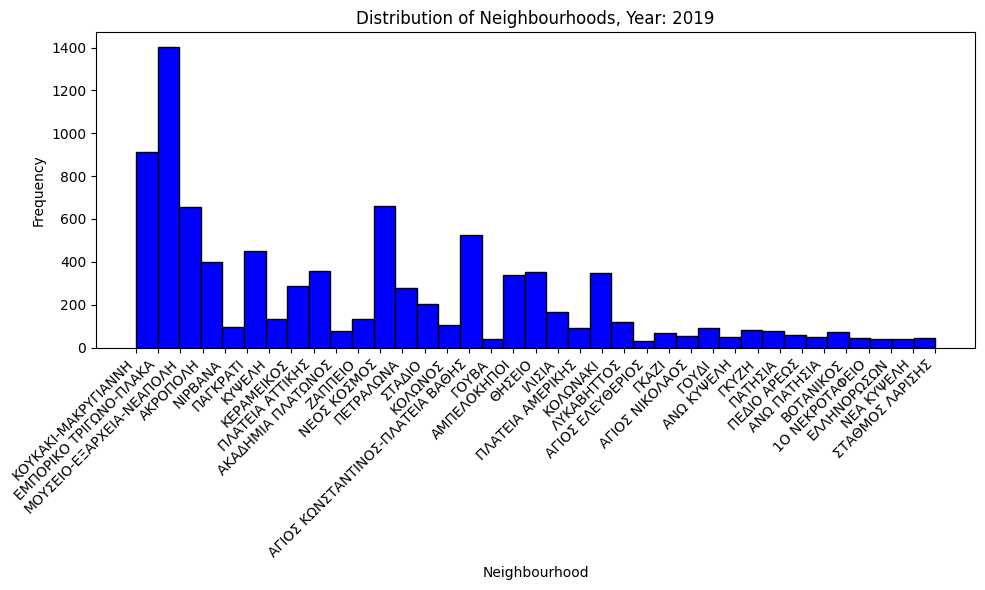

-----Now printing for 2023------


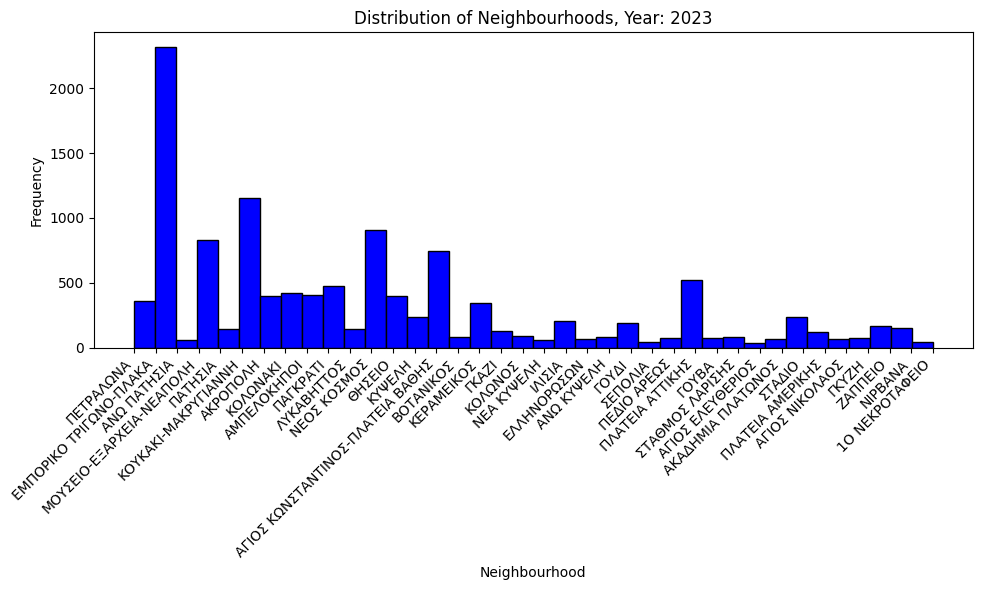

In [ ]:
#Question 1.6

import pandas as pd
import matplotlib.pyplot as plt

def hist_neighbourhoods(csv_list, min_count=30):
  # Load the CSV file
  df = pd.read_csv(csv_list)

  # Count the frequency of each neighborhood
  count_neighbourhoods = df['neighbourhood_cleansed'].value_counts()

  # Filter out neighborhoods with counts below the minimum
  count_neighbourhoods = count_neighbourhoods[count_neighbourhoods >= min_count]

  # Plotting
  plt.figure(figsize=(10, 6))
  plt.hist(df[df['neighbourhood_cleansed'].isin(count_neighbourhoods.index)]['neighbourhood_cleansed'], bins=len(count_neighbourhoods), color='blue', edgecolor='black')
  plt.title(f'Distribution of Neighbourhoods, Year: {csv_list[23:27]}')
  plt.xlabel('Neighbourhood')
  plt.ylabel('Frequency')
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_6_2019.png')
  else :
    plt.savefig('question_1_6_2023.png')

  plt.show()


def main():
  # 2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  hist_neighbourhoods(file_name_19)
  # 2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  hist_neighbourhoods(file_name_23)

if __name__ == '__main__':
  main()


-----Now printing for 2019-----


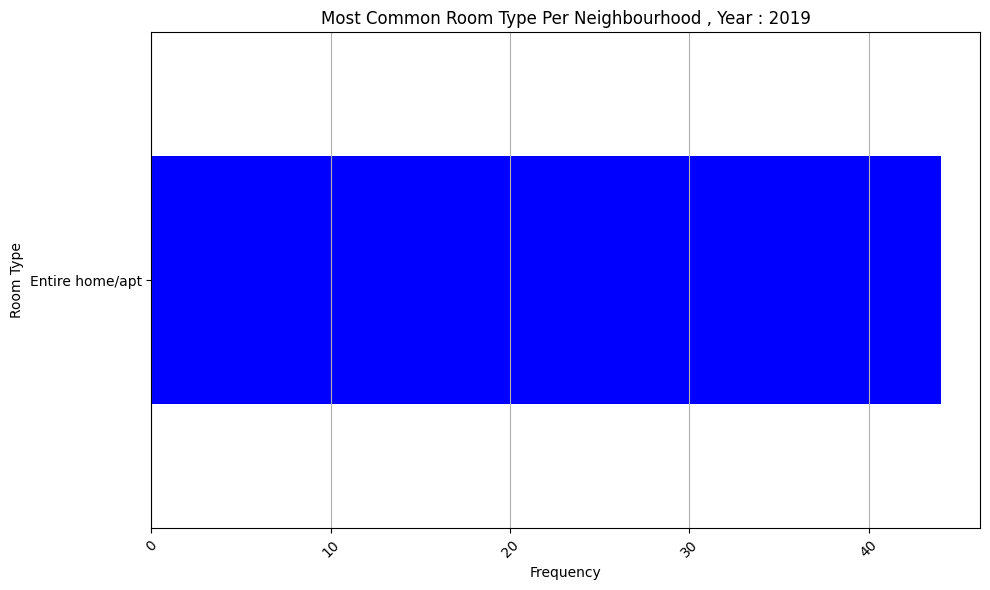

-----Now printing for 2023------


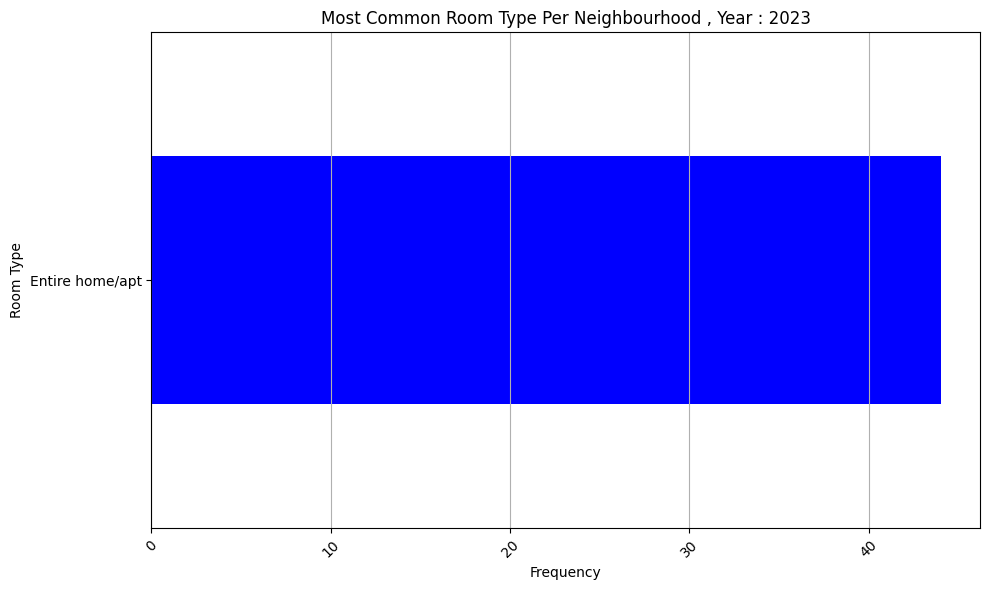

In [ ]:
#Question 1.7
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_find_element_per_neighbourhoods(csv_file, column_name):
  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(csv_file)

  # Find the most common room type per neighbourhood
  group_neighbourhood_room_type = df.groupby('neighbourhood_cleansed')['room_type'].agg(lambda x: x.mode()[0])

  # Plotting
  plt.figure(figsize=(10, 6))
  group_neighbourhood_room_type.value_counts().plot(kind='barh', color='blue')
  plt.title(f'Most Common Room Type Per Neighbourhood , Year : {csv_file[23 : 27]}')
  plt.xlabel('Frequency')
  plt.ylabel('Room Type')
  plt.xticks(rotation=45)
  plt.grid(axis='x')
  plt.tight_layout()
  if csv_file[23 : 27] == '2019' :
    plt.savefig('question_1_7_2019.png')
  else :
    plt.savefig('question_1_7_2023.png')

  plt.show()


def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  type_ = 'room_type'
  plot_find_element_per_neighbourhoods(file_name_19,type_)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  plot_find_element_per_neighbourhoods(file_name_23,type_)


if __name__ == '__main__' :
  main()

-----Now printing for 2019-----


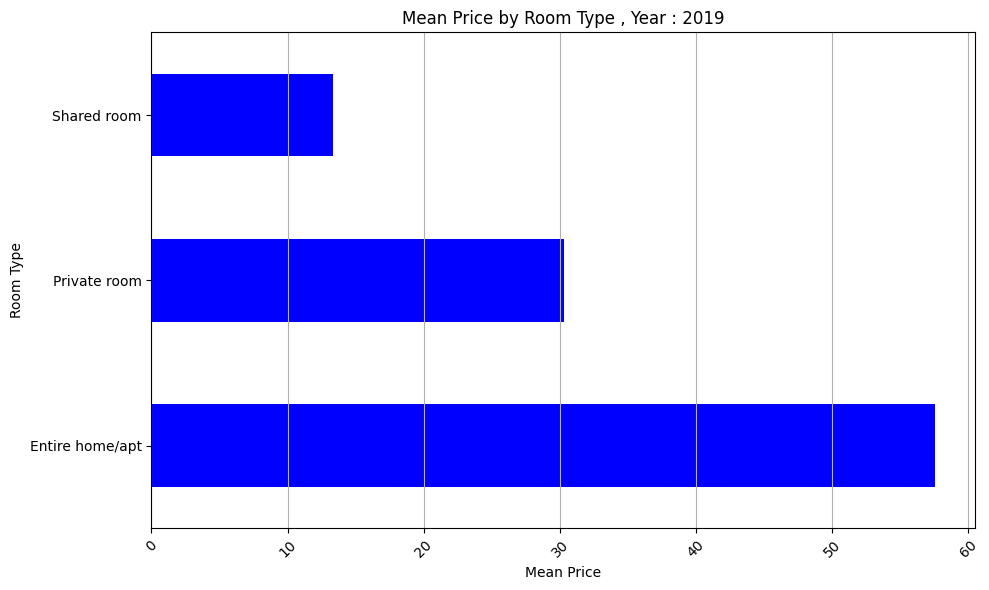

The most expensive room type is: Entire home/apt
-----Now printing for 2023------


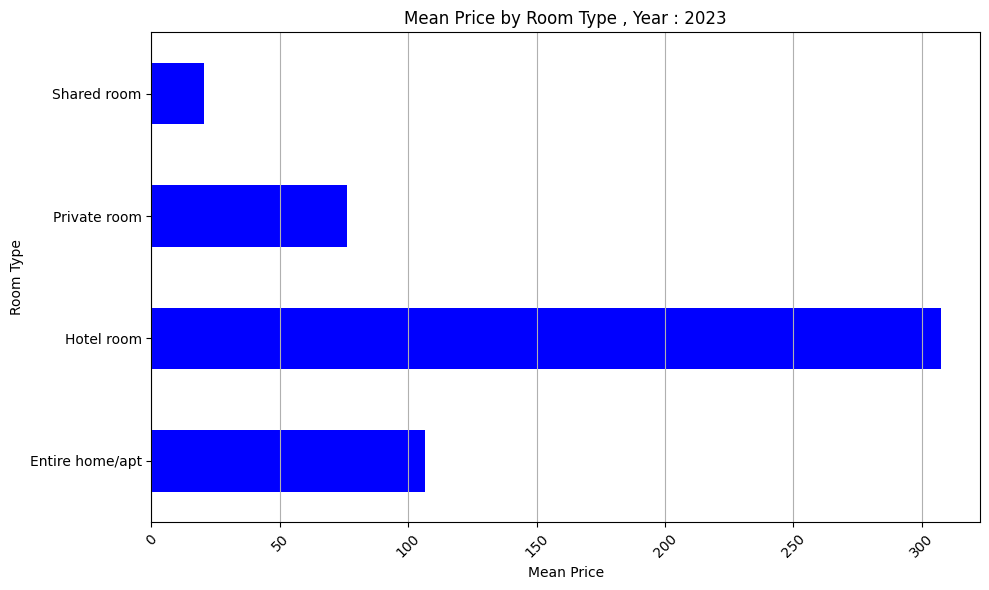

The most expensive room type is: Hotel room


In [ ]:
#Question 1.8
import pandas as pd
import matplotlib.pyplot as plt

def expensive (csv_list,column_name) :

  # Load the CSV file
  df = pd.read_csv(csv_list)

  # Group by 'room_type' and calculate mean price
  group_column_price = df.groupby(column_name)['price'].mean()

  # Find the most expensive room type
  most_expensive = group_column_price.idxmax()

  # Plotting
  plt.figure(figsize=(10, 6))
  group_column_price.plot(kind='barh', color='blue')
  plt.title(f'Mean Price by Room Type , Year : {csv_list[23 : 27]}')
  plt.xlabel('Mean Price')
  plt.ylabel('Room Type')
  plt.xticks(rotation=45)
  plt.grid(axis='x')
  plt.tight_layout()
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_8_2019.png')
  else :
    plt.savefig('question_1_8_2023.png')

  plt.show()


  print("The most expensive room type is:", most_expensive)


def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  type_ = 'room_type'
  expensive(file_name_19,type_)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  expensive(file_name_23,type_)

if __name__ == "__main__" :
  main()

In [ ]:
#Question 1.9
import pandas as pd
import folium

def map_(csv_list) :

  # Load the CSV file into a DataFrame
  df = pd.read_csv(csv_list)

  # Filter the DataFrame for a specific month (e.g., April)
  df['last_review'] = pd.to_datetime(df['last_review'])
  df = df[df['last_review'].dt.month == 4]

  # Create a Folium Map centered around the mean latitude and longitude of the filtered data
  map_center = [df['latitude'].mean(), df['longitude'].mean()]
  mymap = folium.Map(location=map_center, zoom_start=10)

  # Add markers for each hotel/house
  for index, row in df.iterrows():
      popup_html = f"<b>ID:</b> {row['id']}<br>" \
                  f"<b>Bed Type:</b> {row['bed_type']}<br>" \
                  f"<b>Room Type:</b> {row['room_type']}<br>" \
                  f"<b>Transit:</b> {row['transit']}"

      folium.Marker([row['latitude'], row['longitude']], popup=popup_html).add_to(mymap)

  # Save the map to an HTML file
  mymap.save("hotels_map.html")

def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  type_ = 'room_type'
  map_(file_name_19)

if __name__ == "__main__" :
  main()

-----Now printing for 2019-----


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/2019/train_2019.csv'

In [ ]:
#Question 1.10
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def word_cloud_func(csv_list) :

  # Load the CSV file into a DataFrame
  df = pd.read_csv(csv_list)

  # Convert "last_review" column to datetime
  df['last_review'] = pd.to_datetime(df['last_review'])

  # Extract month from "last_review" column
  df['review_month'] = df['last_review'].dt.strftime('%B')


  # Create a function to generate word clouds
  def generate_word_cloud(column_name):
    # Concatenate all values in the specified column
    text = ' '.join(df[column_name].dropna())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # Display the word cloud
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for {column_name} , Year : {csv_list[23 : 27]}")
    plt.axis('off')
    plt.show()


  # Generate word clouds for each column except "last_review"
  columns_to_cloud = ["neighbourhood_cleansed", "transit", "description"]
  for column in columns_to_cloud:
      if column in df.columns :
        generate_word_cloud(column)
      else :
        print(f"Sorry no such column exists in Year : {csv_list[23 : 27]}")

  # Generate word cloud for "review_month" column
  generate_word_cloud("review_month")

def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  word_cloud_func(file_name_19)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  word_cloud_func(file_name_23)

if __name__ == "__main__" :
  main()

Output hidden; open in https://colab.research.google.com to view.

-----Now printing for 2019-----


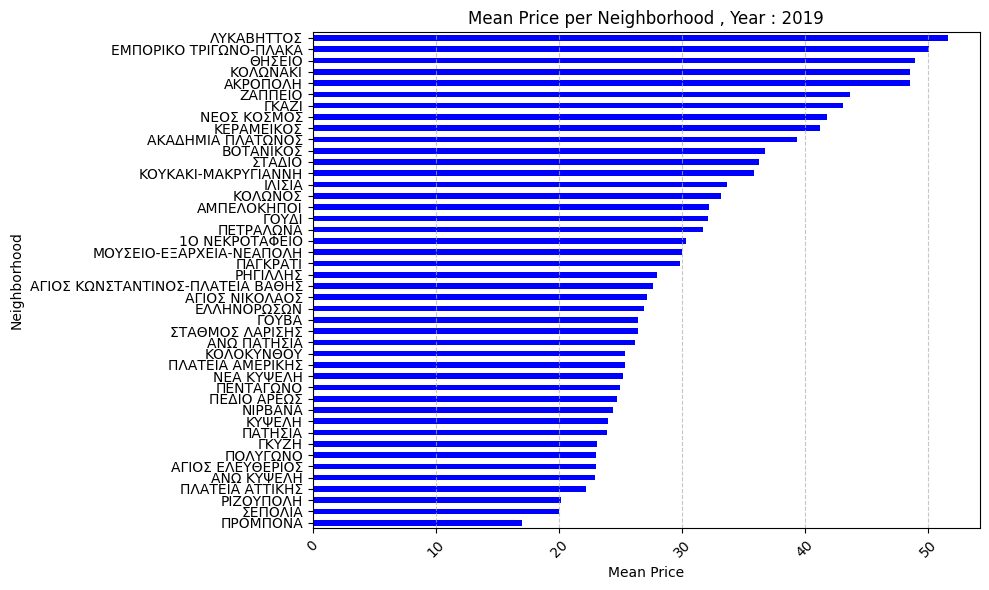

Neighborhood Classification:
neighbourhood_cleansed
ΠΡΟΜΠΟΝΑ                                Economical
ΣΕΠΟΛΙΑ                                 Economical
ΡΙΖΟΥΠΟΛΗ                               Economical
ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ                         Economical
ΑΝΩ ΚΥΨΕΛΗ                              Economical
ΑΓΙΟΣ ΕΛΕΥΘΕΡΙΟΣ                        Economical
ΠΟΛΥΓΩΝΟ                                Economical
ΓΚΥΖΗ                                   Economical
ΠΑΤΗΣΙΑ                                 Economical
ΚΥΨΕΛΗ                                  Economical
ΝΙΡΒΑΝΑ                                 Economical
ΠΕΔΙΟ ΑΡΕΩΣ                             Economical
ΠΕΝΤΑΓΩΝΟ                               Economical
ΝΕΑ ΚΥΨΕΛΗ                              Economical
ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ                        Economical
ΚΟΛΟΚΥΝΘΟΥ                              Economical
ΑΝΩ ΠΑΤΗΣΙΑ                             Economical
ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ                         Economical
ΓΟΥΒΑ                         

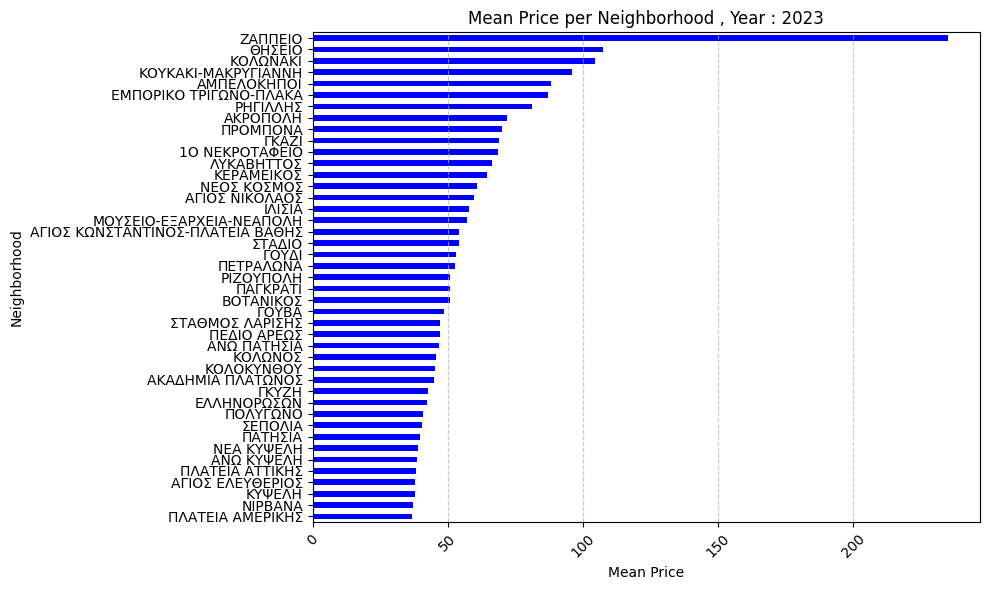

Neighborhood Classification:
neighbourhood_cleansed
ΠΛΑΤΕΙΑ ΑΜΕΡΙΚΗΣ                        Economical
ΝΙΡΒΑΝΑ                                 Economical
ΚΥΨΕΛΗ                                  Economical
ΑΓΙΟΣ ΕΛΕΥΘΕΡΙΟΣ                        Economical
ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ                         Economical
ΑΝΩ ΚΥΨΕΛΗ                              Economical
ΝΕΑ ΚΥΨΕΛΗ                              Economical
ΠΑΤΗΣΙΑ                                 Economical
ΣΕΠΟΛΙΑ                                 Economical
ΠΟΛΥΓΩΝΟ                                Economical
ΕΛΛΗΝΟΡΩΣΩΝ                             Economical
ΓΚΥΖΗ                                   Economical
ΑΚΑΔΗΜΙΑ ΠΛΑΤΩΝΟΣ                       Economical
ΚΟΛΟΚΥΝΘΟΥ                              Economical
ΚΟΛΩΝΟΣ                                 Economical
ΑΝΩ ΠΑΤΗΣΙΑ                             Economical
ΠΕΔΙΟ ΑΡΕΩΣ                             Economical
ΣΤΑΘΜΟΣ ΛΑΡΙΣΗΣ                         Economical
ΓΟΥΒΑ                         

In [ ]:
#Question 1.12
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def mean_price_neighbourhood(csv_list) :
  # Load the CSV file into a DataFrame
  df = pd.read_csv(csv_list)

  # Replace 'N/A' values in 'neighbourhood' column with 'Unknown'
  df['neighbourhood_cleansed'].fillna('Unknown', inplace=True)

  # Filter the data to keep only rows where 'accommodates' column has a value of 2
  df_filtered = df[df['accommodates'] == 2]

  # Calculate the mean price per neighborhood
  mean_price_per_neighborhood = df_filtered.groupby('neighbourhood_cleansed')['price'].mean().sort_values()

  # Plot the neighborhoods sorted by mean price
  plt.figure(figsize=(10, 6))
  mean_price_per_neighborhood.plot(kind='barh', color='blue')
  plt.title(f'Mean Price per Neighborhood , Year : {csv_list[23 : 27]}')
  plt.xlabel('Mean Price')
  plt.ylabel('Neighborhood')
  plt.xticks(rotation=45)
  plt.grid(axis='x', linestyle='--', alpha=0.7)
  plt.tight_layout()
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_12_2019.png')
  else :
    plt.savefig('question_1_12_2023.png')

  plt.show()


  # Classify the neighborhoods into three categories: very expensive, medium, and economical
  mean_price_categories = pd.cut(mean_price_per_neighborhood, bins=3, labels=['Economical', 'Medium', 'Very Expensive'])

  # Print the classification of neighborhoods
  print("Neighborhood Classification:")
  print(mean_price_categories)


def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  mean_price_neighbourhood(file_name_19)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  mean_price_neighbourhood(file_name_23)

if __name__ == '__main__' :
  main()

-----Now printing for 2019-----


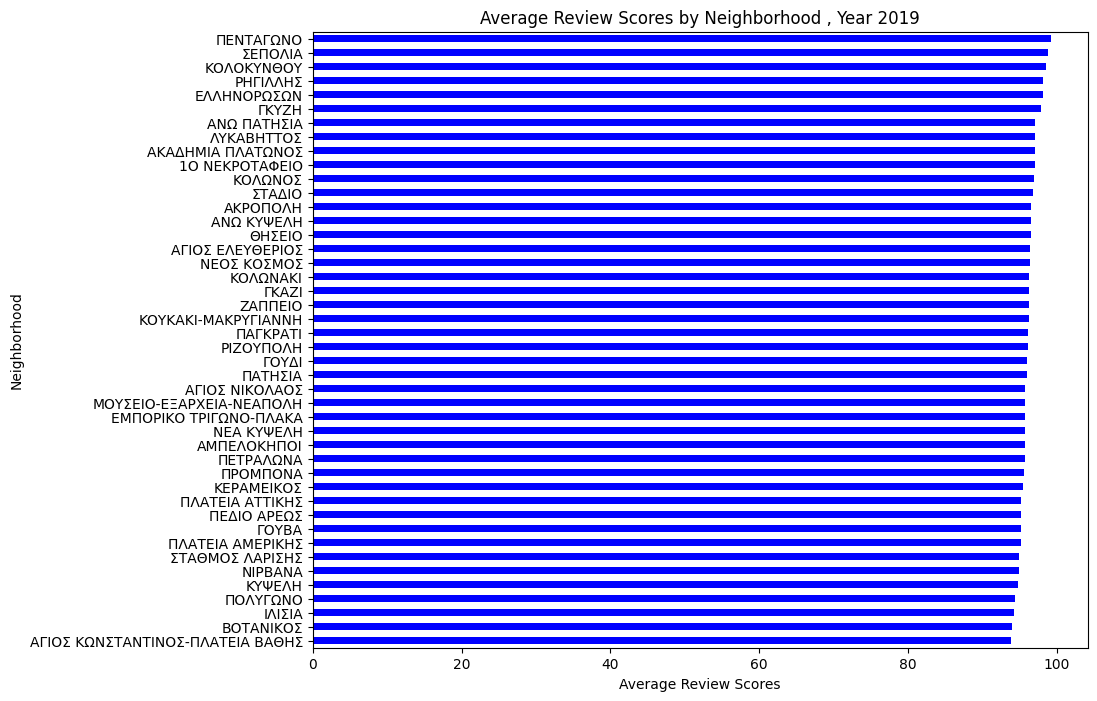

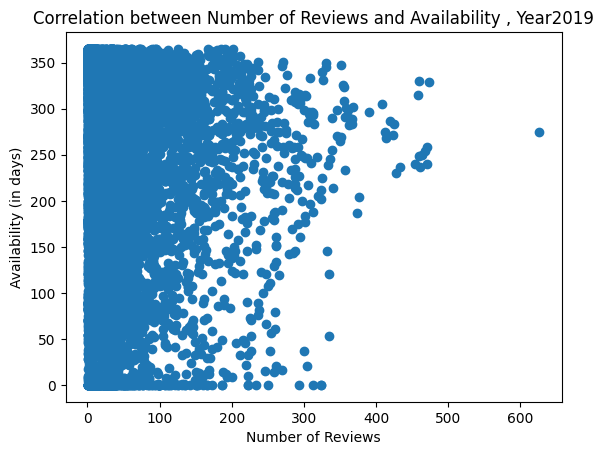

<Figure size 1000x800 with 0 Axes>

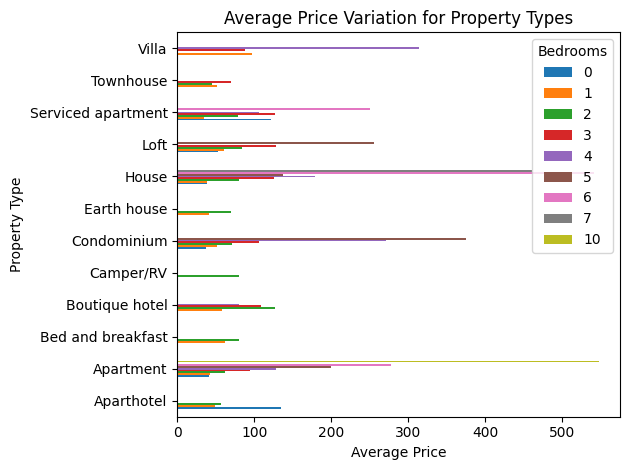

-----Now printing for 2023------


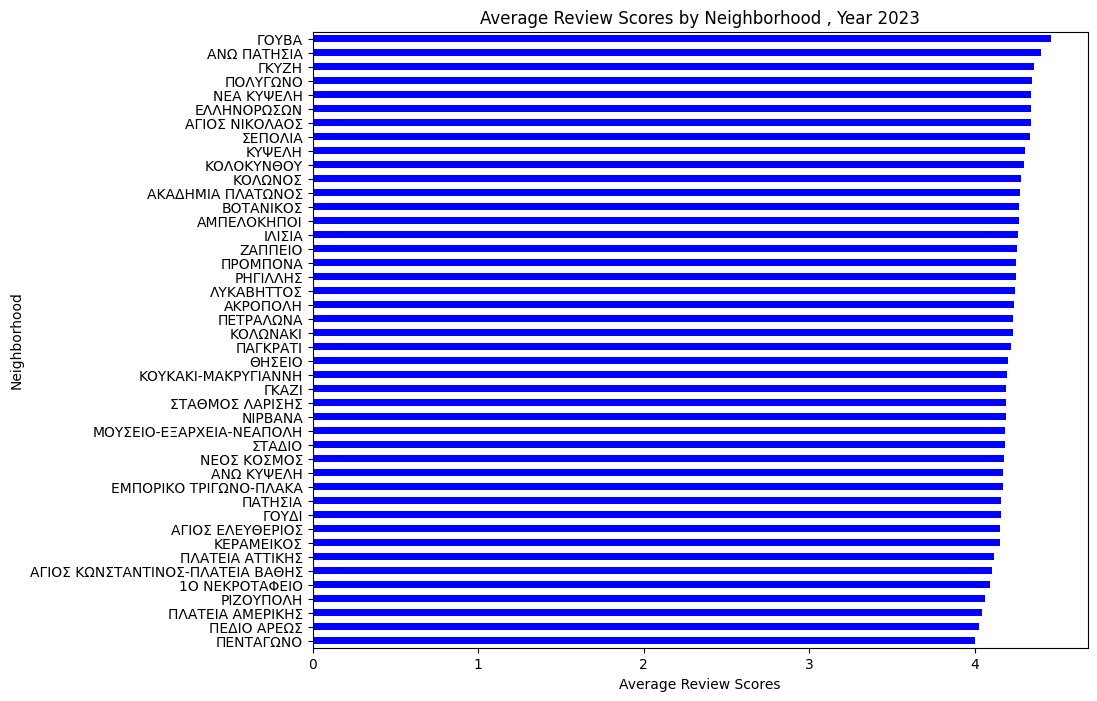

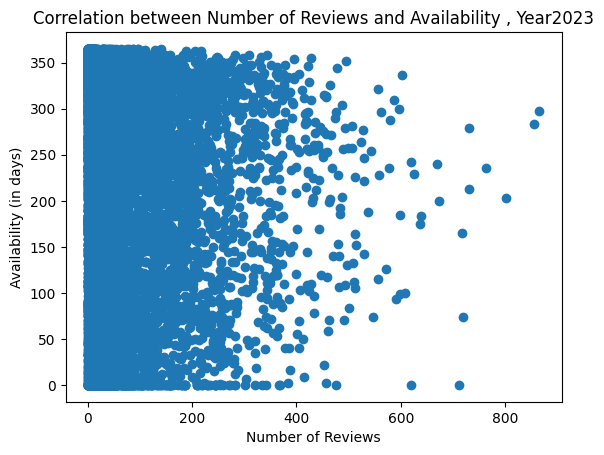

<Figure size 1000x800 with 0 Axes>

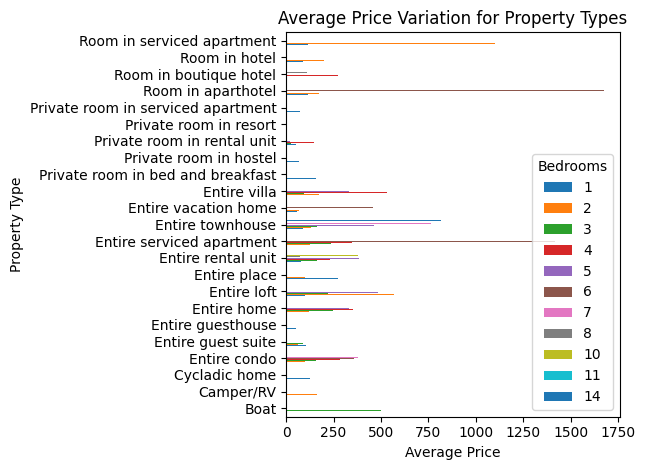

In [ ]:
#Question 1.13
import pandas as pd
import matplotlib.pyplot as plt

def SomeQuestions(csv_list,min_value = 50) :
  # Load the data
  df = pd.read_csv(csv_list)

  # Question 1: Distribution of review scores ratings across different neighborhoods
  neighborhood_review_scores = df.groupby('neighbourhood_cleansed')['review_scores_rating'].mean().sort_values()
  neighborhood_review_scores.plot(kind='barh', figsize=(10,8), color = 'blue')
  plt.xlabel('Average Review Scores')
  plt.ylabel('Neighborhood')
  plt.title(f'Average Review Scores by Neighborhood , Year {csv_list[23 : 27]}')
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_13_a_2019.png')
  else :
    plt.savefig('question_1_13_a_2023.png')
  plt.show()

  # Question 2: Correlation between number of reviews and availability
  plt.scatter(df['number_of_reviews'], df['availability_365'])
  plt.xlabel('Number of Reviews')
  plt.ylabel('Availability (in days)')
  plt.title(f'Correlation between Number of Reviews and Availability , Year{csv_list[23 : 27]}')
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_13_b_2019.png')
  else :
    plt.savefig('question_1_13_b_2023.png')

  plt.show()

  # Question 3: Price variation based on property type and number of bedrooms
  # Filter the data based on mean price greater than 50
  filtered_df = df.groupby('property_type').filter(lambda x: x['price'].mean() > min_value)

  # Price variation based on property type and number of bedrooms
  plt.figure(figsize=(10, 8))
  pivot_table = filtered_df.pivot_table(index='property_type', columns='bedrooms', values='price', aggfunc='mean')
  pivot_table.plot(kind='barh')
  plt.xlabel('Average Price')
  plt.ylabel('Property Type')
  plt.title('Average Price Variation for Property Types')
  plt.legend(title='Bedrooms')
  plt.tight_layout()
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_13_c_2019.png')
  else :
    plt.savefig('question_1_13_c_2023.png')

  plt.show()

def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  SomeQuestions(file_name_19)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  SomeQuestions(file_name_23)


if __name__ == '__main__' :
  main()

-----Now printing for 2019-----


<Figure size 1000x600 with 0 Axes>

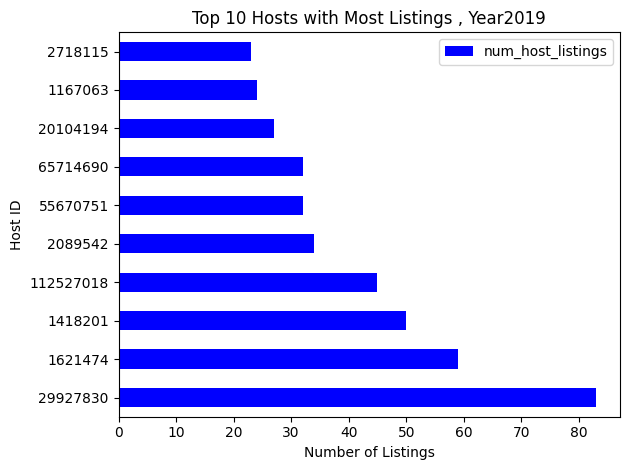

     host_id  num_host_listings
0   29927830                 83
1    1621474                 59
2    1418201                 50
3  112527018                 45
4    2089542                 34
5   55670751                 32
6   65714690                 32
7   20104194                 27
8    1167063                 24
9    2718115                 23
     host_id  num_host_listings
0   29927830                 83
1    1621474                 59
2    1418201                 50
3  112527018                 45
4    2089542                 34
5   55670751                 32
6   65714690                 32
7   20104194                 27
8    1167063                 24
9    2718115                 23
-----Now printing for 2023------


<Figure size 1000x600 with 0 Axes>

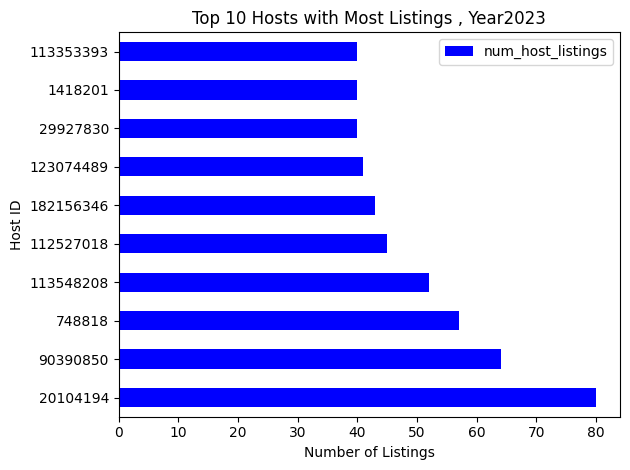

     host_id  num_host_listings
0   20104194                 80
1   90390850                 64
2     748818                 57
3  113548208                 52
4  112527018                 45
5  182156346                 43
6  123074489                 41
7   29927830                 40
8    1418201                 40
9  113353393                 40
     host_id  num_host_listings
0   20104194                 80
1   90390850                 64
2     748818                 57
3  113548208                 52
4  112527018                 45
5  182156346                 43
6  123074489                 41
7   29927830                 40
8    1418201                 40
9  113353393                 40


In [ ]:
#Question 1.14
import pandas as pd
import matplotlib.pyplot as plt

def num_host_listings(csv_list) :
  # Read the CSV file
  df = pd.read_csv(csv_list)

  # Group by host_id and count the number of unique ids for each host
  count_host_list = df.groupby('host_id')['id'].nunique()

  # Sort the hosts by the number of listings and get the top 10 hosts
  fint_top_hst =count_host_list.sort_values(ascending=False).head(10)

  # Create a DataFrame with the top hosts and their number of listings
  top_hosts_df = pd.DataFrame({'host_id': fint_top_hst.index, 'num_host_listings': fint_top_hst.values})

  # Plot the results using pandas plotting
  plt.figure(figsize=(10, 6))
  top_hosts_df.plot(x='host_id', y='num_host_listings', kind='barh', color='blue')
  plt.xlabel('Number of Listings')
  plt.ylabel('Host ID')
  plt.title(f'Top 10 Hosts with Most Listings , Year{csv_list[23 : 27]}')
  plt.tight_layout()
  if csv_list[23 : 27] == '2019' :
    plt.savefig('question_1_14_2019.png')
  else :
    plt.savefig('question_1_14_2023.png')

  plt.show()

  # Print the DataFrame for reference
  print(top_hosts_df)

  # Print the DataFrame for reference
  print(top_hosts_df)

def main() :
  #2019
  print("-----Now printing for 2019-----")
  file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
  num_host_listings(file_name_19)
  #2023
  print("-----Now printing for 2023------")
  file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
  num_host_listings(file_name_23)

if __name__ == '__main__' :
  main()

Ερώτημα 1.15

Με βάση τα δεδομένα και την ανάλυση των γραφημάτων των ετών 2019 και 2023, μπορούμε να εντοπίσουμε διάφορες διαφορές μεταξύ αυτών των δύο ετών. Ακολουθούν οι κυριότερες διαφορές:

**Αριθμός γειτονιών:**

2019: Οι βραχυχρόνιες μισθώσεις επικεντρώνονταν κυρίως σε συγκεκριμένες περιοχές.

2023: Ο αριθμός των γειτονιών με βραχυχρόνιες μισθώσεις αυξήθηκε τόσο σε υπάρχουσες όσο και σε νέες περιοχές.

**Αριθμός ακινήτων και ξενοδοχείων:**

2019: Ο αριθμός των ακινήτων και ξενοδοχείων ήταν μικρότερος.

2023: Παρατηρείται σημαντική αύξηση στον αριθμό των ακινήτων και των ξενοδοχείων.

**Τιμές ιδιοκτησιών:**

2019: Οι τιμές παρέμεναν σε σχετικά σταθερά επίπεδα, με κάποιες μικρές αυξομειώσεις.

2023: Οι τιμές των ιδιοκτησιών παρουσίασαν μεγάλη αύξηση σε αρκετές περιπτώσεις, αν και σε ορισμένες περιοχές παρέμειναν σταθερές.

**Ακριβές γειτονιές:**

2019: Οι ακριβές γειτονιές διατηρούσαν σταθερές τιμές.

2023: Κάποιες ακριβές γειτονιές δεν παρουσίασαν μεγάλη αλλαγή στις τιμές τους, ενώ άλλες σημείωσαν σημαντική αύξηση.

**Ξενοδοχεία και επισκεψιμότητα:**

2019: Ο αριθμός των ξενοδοχείων και των επισκεπτών ήταν χαμηλότερος.

2023: Υπήρξε αύξηση στον αριθμό των ξενοδοχείων, καθώς και στον αριθμό των επισκεπτών σε αυτά.

Από αυτά τα δεδομένα, το γενικό συμπέρασμα είναι ότι υπήρξε σημαντική ανάπτυξη και αύξηση στις βραχυχρόνιες μισθώσεις, στις τιμές των ακινήτων και στον τουρισμό μεταξύ των ετών 2019 και 2023.

In [ ]:
#Second part
import random
import pandas as pd
import numpy as np
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

#Quesion 2.1
def TF_IDF(csv_list) :
  # Load your CSV file into a pandas DataFrame
  df = pd.read_csv(csv_list)

  # Concatenate 'name' and 'description' columns
  df['name_description'] = df['name'].fillna('NULL') + ' ' + df['description'].fillna('NULL')

  # Drop duplicates based on the concatenated column
  df.drop_duplicates(subset='name_description', inplace=True)

  # Combine 'name_description' and 'description' for TF-IDF
  text_data = df['name_description'] + ' ' + df['description']

  # Remove stopwords and create TF-IDF matrix
  stop_words = list(text.ENGLISH_STOP_WORDS.union(["your", "additional", "stopwords", "here"]))
  tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1, 2))
  tfidf_matrix = tfidf_vectorizer.fit_transform(text_data)
  tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

  N = 10
  # Display top N most frequent words
  top_words = tfidf_df.sum().sort_values(ascending=False).head(N)
  # print("Top words in combined text after removing stopwords:")
  # print(top_words)

  cosine_similarity_func(tfidf_df,df)
  Frequent_Words(text_data)

#Question 2.2
def cosine_similarity_func(tfidf_matrix,df) :
  # Convert the DataFrame to a CSR sparse matrix
  sparse_tfidf_matrix = csr_matrix(tfidf_matrix.values)

  # Store the row indices separately
  row_indices = tfidf_matrix.index

  # Calculate cosine similarity between each pair of houses/hotels
  similarity_matrix = cosine_similarity(sparse_tfidf_matrix)

  # Initialize a dictionary to store similarity scores
  similar_houses = {}

  # Iterate through each house/hotel
  for i, house_id in enumerate(row_indices):
    # Get similarity scores for the current house/hotel
    similarities = [(row_indices[j], similarity_matrix[i][j]) for j in range(len(row_indices)) if j != i and row_indices[j] != house_id]

    # Sort similarity scores in descending order
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Keep only the top 100 most similar houses/hotels
    similar_houses[house_id] = similarities[:100]

  # Remove IDs from the dictionary that are not present in the DataFrame
  similar_houses = {house_id: similarities for house_id, similarities in similar_houses.items() if house_id in df.index}

  house_id_input = random.choice(list(similar_houses.keys()))
  N = input("Give an integer N : ")
  print()
  top_n_similarities = recommend(similar_houses,int(house_id_input),int(N),df)

#Question 2.3
def recommend(similar_houses, house_id, N,df):

  if house_id not in similar_houses:
    print(f"No similar houses found for house/hotel ID: {house_id}")
    return []

  # Get similarity scores for the specified house/hotel ID
  similarities = similar_houses[house_id]

  # Sort similarity scores in descending order
  similarities.sort(key=lambda x: x[1], reverse=True)

  # Keep track of how many recommendations have been printed
  printed_recommendations = 0

  name_id = df.loc[house_id, 'name']
  print(f"Recommending {N} listings similar to {name_id}")
  print("--------------------")
  print()

  # Print information about the top N similar houses/hotels
  for house_info in similarities:
    index = house_info[0]
    # Check if index exists in DataFrame
    if index in df.index:
      # Access house name and description
      house_name = df.loc[index, 'name']
      house_description = df.loc[index, 'description']
      similarity_score = house_info[1]

      print(f"Recommended: {house_name}")
      print(f"Description: {house_description}")
      print(f"(score: {similarity_score})")
      print()

      printed_recommendations += 1

      # Check if N recommendations have been printed
      if printed_recommendations == N:
        break

  return similarities[:N]  # Return the top N similar houses/hotels

#Question 2.4
def Frequent_Words(text_data) :

  # Convert text_data to lowercase
  text_data_lower = text_data.str.lower()

  # Tokenize text_data into words
  words_list = text_data_lower.str.split()

  # Remove stopwords
  stop_words = set(text.ENGLISH_STOP_WORDS.union(["your", "additional", "stopwords", "here"]))
  words_list_no_stopwords = [[word for word in words if word not in stop_words] for words in words_list]

  # Flatten the list of lists into a single list of words
  words = [word for sublist in words_list_no_stopwords for word in sublist]

  # Finding frequent bigrams
  finder = BigramCollocationFinder.from_words(words)
  bigram_measures = BigramAssocMeasures()
  top_bigrams = finder.nbest(bigram_measures.raw_freq, 10)
  print("Top 10 frequent bigrams:")
  for bigram_ in top_bigrams :
    print(bigram_)

def main() :
  year = input("Choose year : ")
  if int(year) == 2019 :
    #2019
    print("-----Now printing for 2019-----")
    file_name_19 = '/content/drive/MyDrive/2019/train_2019.csv'
    TF_IDF(file_name_19)
  else :
    #2023
    print("-----Now printing for 2023------")
    file_name_23 = '/content/drive/MyDrive/2023/train_2023.csv'
    TF_IDF(file_name_23)


if __name__ == '__main__' :
  main()

Choose year : 2019
-----Now printing for 2019-----
Give an integer N : 5

Recommending 5 listings similar to STUDIO APT. IN ATHENS HEART
--------------------

Recommended: Historical center
Description: Fully furnished refurbished completely July 2017 central flat in Ermou street the most well known pedestrian road of Athens The flat boasts a modern atmosphere with a comfortable large queen size bed and a large sofa bed that sleeps easily 2 people. The WC shower is brand new and it comes with all mod cons and shower bath amenities. The kitchen comes with a built in bar and all mod cons electric kitchen with stove, microwave coffee maker and kettle plus a large fridge. All kitchen amenities are there to enjoy cooking in house. The lounge comes with a fully comfortable dining table to enjoy your meal and a sofa area to rest and enjoy your large plasma TV. Fully airconditioned area and a lovely view of Ermou street. The flat is fully insulated so whilst you are in the middle of everything